In [2]:
from config import client
import pandas as pd

In [5]:
batch_number_out_query = """
SELECT * FROM zoho_books_analytics.batch_number_out
"""

result = client.query(batch_number_out_query)

batch_number_out_df = pd.DataFrame(result.result_rows, columns=[col for col in result.column_names])

In [6]:
batch_number_out_df.columns

Index(['batch_out_id', 'batch_in_id', 'warehouse_id', 'product_id',
       'quantity_out', 'entity_type', 'invoice_id', 'invoice_item_id',
       'vendor_credit_id', 'vendor_credits_item_id', 'inventory_adjustment_id',
       'inventory_adjustment_item_id', 'bundle_id', 'bundle_item_id',
       'created_time', 'last_modified_time', 'package_id', 'package_item_id'],
      dtype='object')

In [9]:
batch_number_out_df.describe()

,batch_out_id,batch_in_id,warehouse_id,product_id,quantity_out,entity_type,invoice_id,invoice_item_id,vendor_credit_id,vendor_credits_item_id,inventory_adjustment_id,inventory_adjustment_item_id,bundle_id,bundle_item_id,created_time,last_modified_time,package_id,package_item_id
count,109782,109782,109782,109782,109782,109782,109782,109782,109782,109782,109782,109782,109782,109782,109782,109782,109782,109782
unique,109782,39451,74,1892,3671,4,44361,90380,581,1160,2622,4738,1,1,NaN,NaN,1,1
top,1410873000000528393,1410873000009172962,1410873000048741070,1410873000000669376,1920.00,invoice,,,,,,,,,NaN,NaN,,
freq,1,75,15738,3609,3656,101541,8241,8241,108614,108614,102709,102709,109782,109782,NaN,NaN,109782,109782
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-05-11 14:30:20.385910528+00:00,2023-05-12 01:53:46.987966976+00:00,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-08-05 02:32:51+00:00,2018-08-05 02:32:51+00:00,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-11-08 20:17:23.750000128+00:00,2021-11-09 04:31:26.500000+00:00,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-08 12:46:47+00:00,2024-01-08 17:42:42+00:00,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-09 13:14:20+00:00,2025-01-09 20:33:34+00:00,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-15 20:22:41+00:00,2025-09-15 20:22:41+00:00,NaN,NaN


In [22]:
batch_number_out_df['quantity_out'].describe()

count    109782.000000
mean       6479.633132
std       10839.676076
min           1.000000
25%         685.000000
50%        1665.000000
75%        4950.000000
max       44000.000000
Name: quantity_out, dtype: float64

In [24]:
batch_number_out_df[batch_number_out_df['quantity_out'] > 44000]

,batch_out_id,batch_in_id,warehouse_id,product_id,quantity_out,entity_type,invoice_id,invoice_item_id,vendor_credit_id,vendor_credits_item_id,inventory_adjustment_id,inventory_adjustment_item_id,bundle_id,bundle_item_id,created_time,last_modified_time,package_id,package_item_id


In [20]:
# convert to float
batch_number_out_df['quantity_out'] = batch_number_out_df['quantity_out'].astype(float)

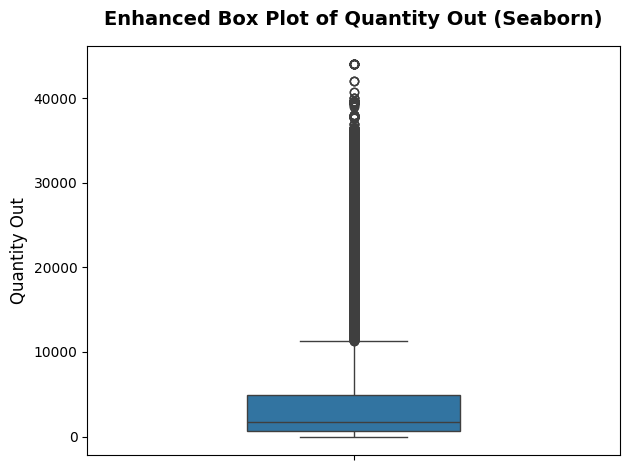

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# Drop NaN values for plotting
plot_data = batch_number_out_df['quantity_out'].dropna()

sns.boxplot(y=plot_data, width=0.4)
plt.title('Enhanced Box Plot of Quantity Out (Seaborn)', fontsize=14, weight='bold', pad=15)
plt.ylabel('Quantity Out', fontsize=12)

# Adjust layout to prevent clipping
plt.tight_layout()

# Show the plot
plt.show()

In [31]:
batch_number_out_df['entity_type'].value_counts()

entity_type
invoice                             101541
inventory_adjustment_by_quantity      5298
transfer_order                        1775
vendor_credit                         1168
Name: count, dtype: int64

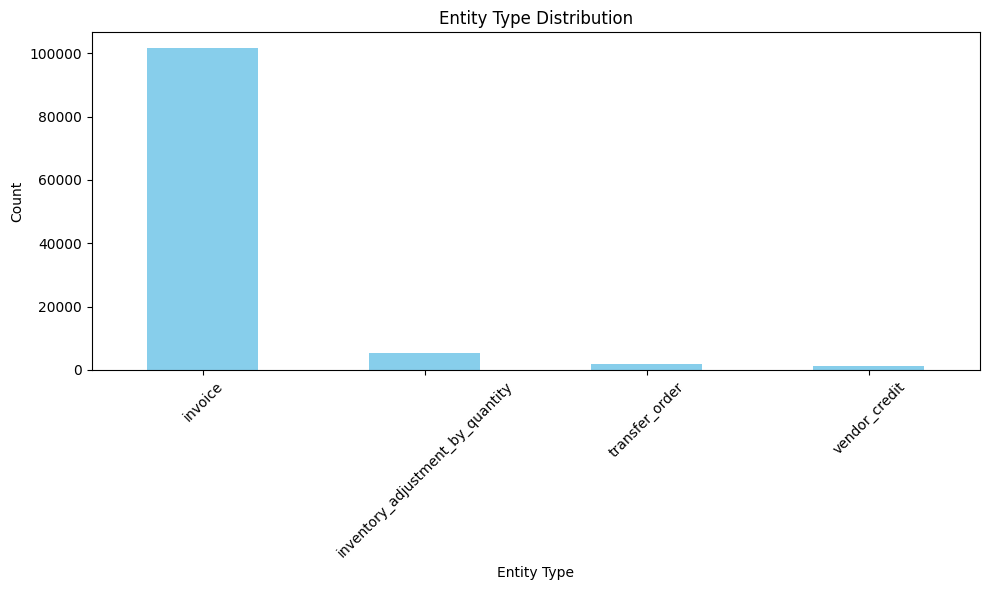

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

counts = batch_number_out_df['entity_type'].value_counts()

# Create bar graph
plt.figure(figsize=(10, 6))
counts.plot(kind='bar', color='skyblue')
plt.title('Entity Type Distribution')
plt.xlabel('Entity Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()